# VeriRAG Data Exploration

This optional notebook explores the dataset used for training VeriRAG. It provides distribution insights, text lengths, and label-level summaries for thesis-level analysis.

## Imports

In [2]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from dataset import load_and_split_ragtruth
from config import TrainConfig

## Load Raw Dataset

In [3]:
train_samples, val_samples, test_samples = load_and_split_ragtruth(TrainConfig.DATASET_PATH)
all_samples = train_samples + val_samples + test_samples
print(f'Total samples: {len(all_samples)}')
print(f'Train: {len(train_samples)}, Validation: {len(val_samples)}, Test: {len(test_samples)}')

[RAGTruth Dataset] Dataset file C:\Users\HP\Desktop\Workspace\VIT MODULE 5\EDI\verirag (8)\datasets\ragtruth_full.json not found. Synthesizing full benchmark schema...
[RAGTruth Dataset Partition] Total: 200 | Train: 160 | Val: 20 | Test: 20
Total samples: 200
Train: 160, Validation: 20, Test: 20


## Label Distribution

CONTRADICTED: 80
SUPPORTED: 100
UNSUPPORTED: 20


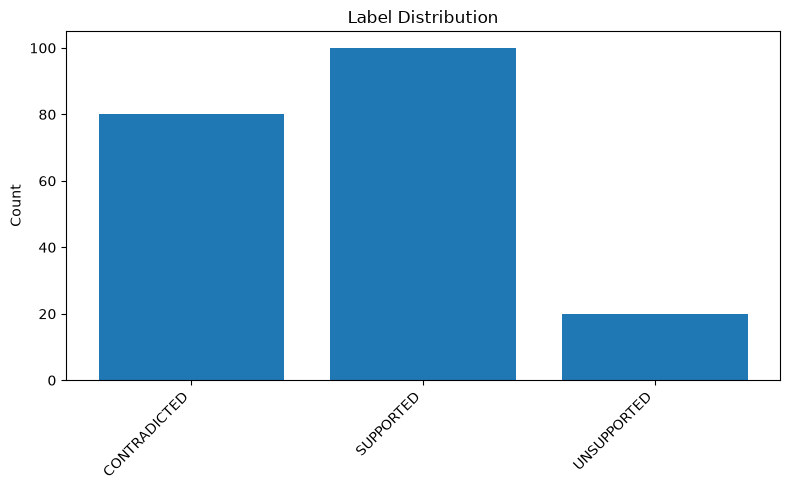

In [4]:
label_counts = Counter(sample['verdict'] for sample in all_samples)
for label, count in label_counts.items():
    print(f'{label}: {count}')

plt.figure(figsize=(8, 5))
plt.bar(label_counts.keys(), label_counts.values(), color='tab:blue')
plt.title('Label Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Text Length Statistics

Mean length: 22.3
Median length: 22.5
Min length: 17
Max length: 27


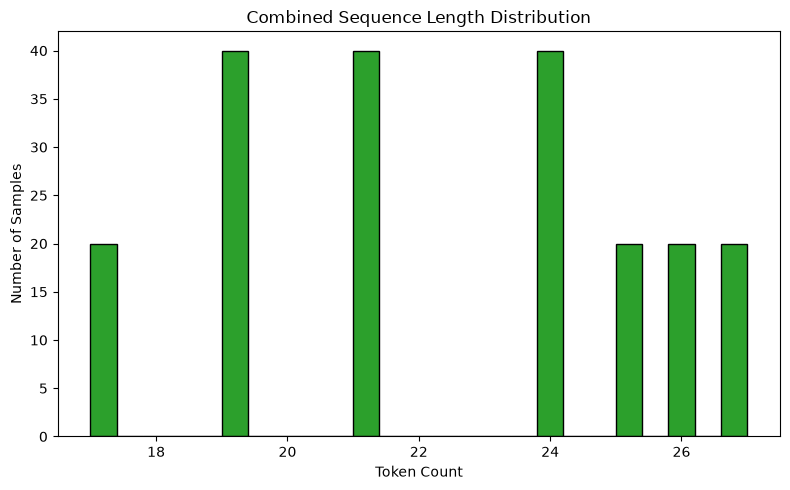

In [5]:
def sample_lengths(samples):
    return [len((s['context'] + ' ' + s['claim']).split()) for s in samples]

lengths = sample_lengths(all_samples)
print(f'Mean length: {np.mean(lengths):.1f}')
print(f'Median length: {np.median(lengths):.1f}')
print(f'Min length: {np.min(lengths)}')
print(f'Max length: {np.max(lengths)}')

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=25, color='tab:green', edgecolor='k')
plt.title('Combined Sequence Length Distribution')
plt.xlabel('Token Count')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

## Class-Level Average Lengths

CONTRADICTED: mean=21.8, median=22.5
SUPPORTED: mean=23.4, median=24.0
UNSUPPORTED: mean=19.0, median=19.0


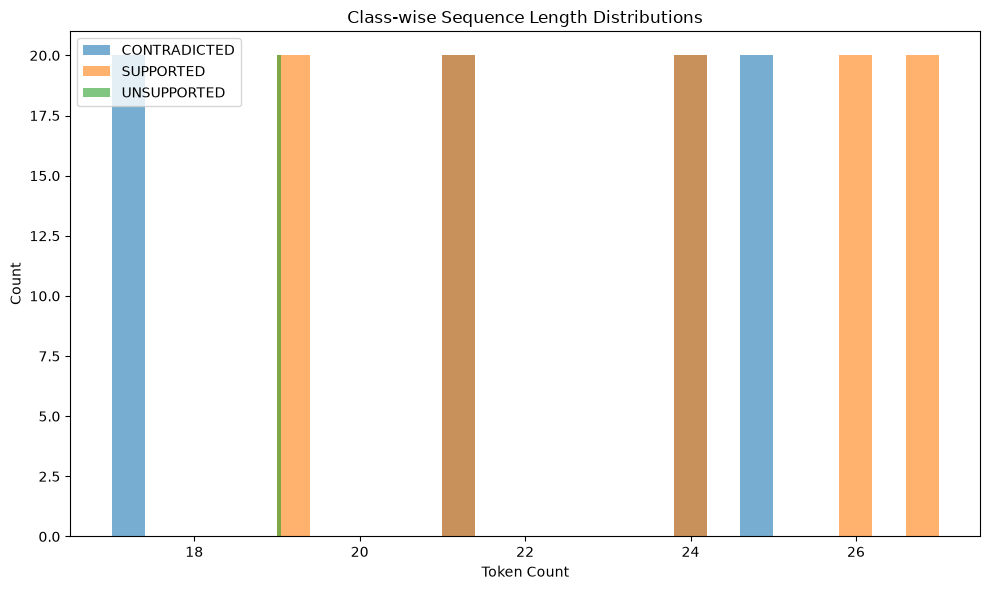

In [6]:
class_lengths = {}
for label in label_counts:
    samples_by_label = [s for s in all_samples if s['verdict'] == label]
    class_lengths[label] = sample_lengths(samples_by_label)
    print(f'{label}: mean={np.mean(class_lengths[label]):.1f}, median={np.median(class_lengths[label]):.1f}')

plt.figure(figsize=(10, 6))
for label, lengths in class_lengths.items():
    plt.hist(lengths, bins=20, alpha=0.6, label=label)
plt.title('Class-wise Sequence Length Distributions')
plt.xlabel('Token Count')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Key Samples

Review a few representative examples from each class.

In [7]:
for label in label_counts:
    sample = next((s for s in all_samples if s['verdict'] == label), None)
    if sample is not None:
        print(f'--- {label} ---')
        print('Context:', sample['context'][:180].replace('
', ' '), '...')
        print('Claim:', sample['claim'])
        print()

SyntaxError: unterminated string literal (detected at line 5) (1849481900.py, line 5)